In [7]:
import pybamm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from scipy import constants
from pybamm import Scalar

current_directory = os.getcwd()

parameter_values = pybamm.ParameterValues("OKane2022") # "lithium plating": "partially reversible",
options = {"thermal": "lumped","lithium plating": "irreversible","SEI":"ec reaction limited", "SEI film resistance":"average", "SEI porosity change": "true","loss of active material": "stress-driven","particle mechanics":"swelling only"} #"lithium plating": "irreversible",

model = pybamm.lithium_ion.DFN(options=options)
# pybamm.set_logging_level("DEBUG")

In [8]:
# %load std500cycles_tuneparameters.py
#Parameters tuned for 500 cycles standard
parameter_values.update({"Total heat transfer coefficient [W.m-2.K-1]": 10.0,})
#thermal parameters update
parameter_values.update({"Negative electrode OCP entropic change [V.K-1]": -0.0002,
                         "Positive electrode OCP entropic change [V.K-1]": -0.0004,
                         "Contact resistance [Ohm]": 0.001,
                        })
def ec_diffusivity(T_amb):
    D_sj = 2.5e-22*4*10*3*2 
    EaD = 10000
    arrhenius = np.exp(EaD / pybamm.constants.R *(1/ 298.15 - 1/ T_amb))
    return D_sj * arrhenius


parameter_values.update({"EC diffusivity [m2.s-1]": ec_diffusivity})
#sei parameters update
parameter_values.update({"SEI kinetic rate constant [m.s-1]": 1e-12*0.002*0.5}) 
parameter_values.update({"SEI growth activation energy [J.mol-1]": 48000.0,
                         "SEI partial molar volume [m3.mol-1]": 9.585e-05*0.4,
                         "SEI resistivity [Ohm.m]": 200000.0
                         })  
# LAM parameters update

parameter_values.update({"Positive electrode LAM constant proportional term [s-1]": 0.1*0.5*1.5/3600,
                         "Negative electrode LAM constant proportional term [s-1]": 0.19*0.5*1.5/3600,
                         
                         "Positive electrode LAM constant exponential term": 2.0*1.1,
                         "Negative electrode LAM constant exponential term": 2.0*1.1,
                         
                         })





#Plating paremeters update
parameter_values.update({
                        "Lithium plating kinetic rate constant [m.s-1]": 1e-09*0.001,
                        
                        })


In [9]:
current_directory

'/home/ganmad/batterycode/pybammlocal/PyBaMMlocal/wip'

In [10]:
experiment0 = pybamm.Experiment(
    [
        (
            "Charge at 0.33C until 4.2 V",
            "Hold at 4.2 V until 50 mA",
            "Rest for 10 min (1 minute period)",
            "Discharge at 0.33C until 2.85 V",
            "Rest for 20 min (1 minute period)",
        )    
    ]
    * 1000,
    termination= "80% capacity"
)

In [11]:
from itertools import product


temp_list = [10, 25, 40] #25,
crate_list = [0.33] #,[0.1,0.3, 1]
soc_list = [100] #,[10, 60, 100] 
dod_list = [90] #60, 70,[50, 70, 90]

all_cases = list(product(temp_list, crate_list, soc_list, dod_list))

df = pd.DataFrame(all_cases,columns = ["Temperature", "C_rate", "SoC", "DoD"])
df.insert(0, "Case", range(1, len(df)+1))
df.to_csv(f"{current_directory}/paperstudies2026/tuning/Cases_tuning_std_cycle_500.csv", index=False)

Cycling:  24%|██▎       | 235/1000 [08:56<29:06,  2.28s/it]


Took 8 minutes, 22 seconds


Cycling:  49%|████▉     | 489/1000 [19:35<20:28,  2.40s/it]


Took 18 minutes, 25 seconds


Cycling:  39%|███▉      | 392/1000 [16:13<25:10,  2.48s/it]


Took 15 minutes, 10 seconds


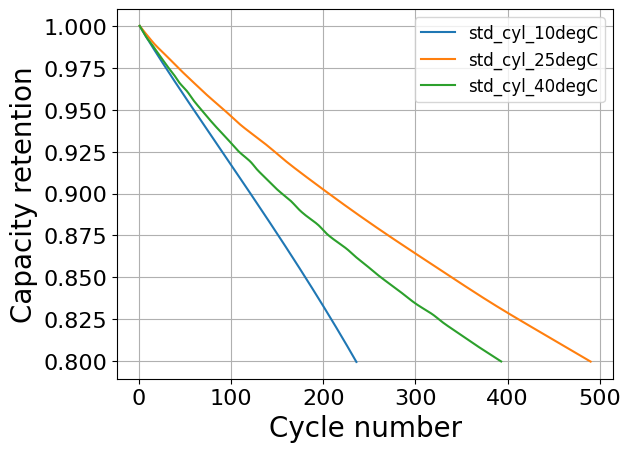

In [12]:

safe_solver = pybamm.IDAKLUSolver(options={"dt_max": 10}) #mode="safe", ,  dt_max= dt_max, return_solution_if_failed_early=True, dt_max= 5.0,root_tol=1e-3, rtol=1e-3, on_failure = "ignore",
#safe_solver = pybamm.CasadiSolver()
for n in range(len(df)): #range(1):#range(1):#
    tempC_case = df["Temperature"][n]
    simcase = df["Case"][n]
    dod_case = df["DoD"][n]*0.01
    soc_case = df["SoC"][n]*0.01
    crate = df["C_rate"][n]
    
    parameter_values.update({"Ambient temperature [K]": 273.15 + tempC_case,
                            "Initial temperature [K]": 273.15 + tempC_case})
    
    sim1 = pybamm.Simulation(model=model, parameter_values=parameter_values, experiment=experiment0, solver=safe_solver)
    sol1 = sim1.solve(showprogress=True, ) #save_at_cycles=50
    print("Took", sol1.solve_time)
    Q1 = sim1.solution.summary_variables["Capacity [A.h]"]
    cycle1 = sim1.solution.summary_variables["Cycle number"]
    Qpl=  sim1.solution.summary_variables["Loss of capacity to negative lithium plating [A.h]"]

    mlam_n = sim1.solution.summary_variables['Loss of active material in negative electrode [%]']
    mlam_p = sim1.solution.summary_variables['Loss of active material in positive electrode [%]']
    Qlli = sim1.solution.summary_variables['Loss of lithium inventory [%]']
    Qside = sim1.solution.summary_variables["Total capacity lost to side reactions [A.h]"]
    Qsei  = sim1.solution.summary_variables['Loss of capacity to negative SEI [A.h]']

    df2 = {}
    df2 = pd.DataFrame(df2)
    df2["Cycle number"] =cycle1
    df2["Capacity Retention"] = Q1/Q1[0]
    df2["LAMpe_per"] =mlam_p
    df2["LAMne_per"] =mlam_n
    df2["Qsei"] = Qsei
    df2["Qpl"] = Qpl
    df2["LLIp"] = Qlli
    df2["Qside"] = Qside


    df2.to_csv(f"{current_directory}/paperstudies2026/tuning/tune_Case{simcase}_{tempC_case}degC_std_cycle_500.csv")

    plt.plot(cycle1,Q1/Q1[0], label =f"std_cyl_{tempC_case}degC")  #_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD_{cycles_per_day}cycle")
    plt.legend(fontsize=12)

plt.xlabel("Cycle number", fontsize =20)
plt.ylabel("Capacity retention", fontsize =20)
plt.xticks(fontsize =16)
plt.yticks(fontsize = 16)
plt.grid(True)
plt.show()

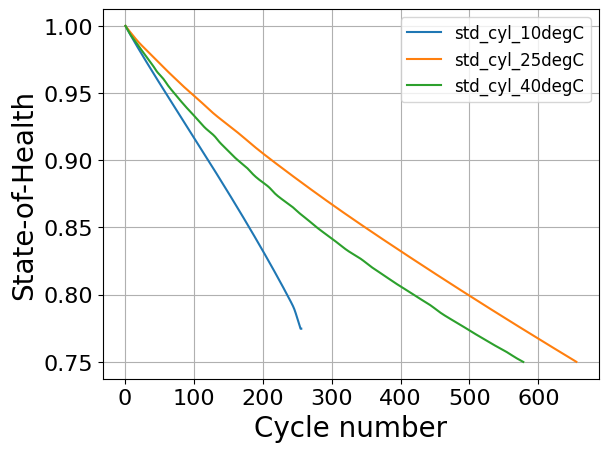

In [ ]:
df3 = pd.read_csv(f"{current_directory}/paperstudies2026/tuning/Cases_tuning_std_cycle_500.csv")
cycles_per_day =1

for m in range(3):#,29,31,33,35,37,39,43,45,47,49,51,53,59,65,67,69,71,77,81]: #range(27,54):#: #range(5): #
   
    n = m
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    dod_case = df3["DoD"][n]*0.01
    soc_case = df3["SoC"][n]*0.01
    crate = df3["C_rate"][n]
    df4 = pd.read_csv(f"{current_directory}/paperstudies2026/tuning/tune_Case{simcase}_{tempC_case}degC_std_cycle_500.csv")
    plt.plot(df4["Cycle number"],df4["Capacity Retention"], label =f"std_cyl_{tempC_case}degC")  #_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD_{cycles_per_day}cycle")
    plt.legend(fontsize=12)

plt.xlabel("Cycle number", fontsize =20)
plt.ylabel("State-of-Health", fontsize =20)
plt.xticks(fontsize =16)
plt.yticks(fontsize = 16)
plt.grid(True)
plt.show()    
    

In [78]:
# safe_solver = pybamm.IDAKLUSolver(options={"dt_max": 10}) #mode="safe", ,  dt_max= dt_max, return_solution_if_failed_early=True, dt_max= 5.0,

# parameter_values.update({"Ambient temperature [K]": 273.15+40,
#                         "Initial temperature [K]": 273.15+40 })

# sim1 = pybamm.Simulation(model=model, parameter_values=parameter_values, experiment=experiment0, solver=safe_solver) #
# sol1 = sim1.solve(showprogress=True)
# print("Took", sol1.solve_time)



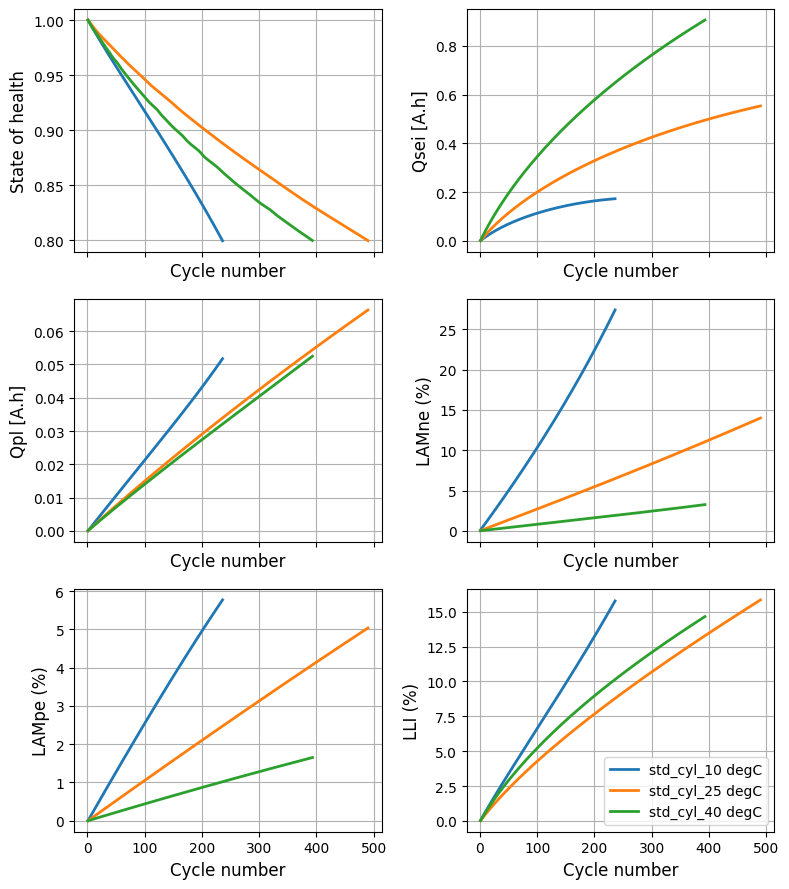

In [13]:
df3 = pd.read_csv(f"{current_directory}/paperstudies2026/tuning/Cases_tuning_std_cycle_500.csv")
cycles_per_day =1


fig, axes = plt.subplots(3, 2, figsize=(8,9), sharex=True)
axes = axes.flatten()
for m in range(3):#,29,31,33,35,37,39,43,45,47,49,51,53,59,65,67,69,71,77,81]: #range(27,54):#: #range(5): #
   
    n = m
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    dod_case = df3["DoD"][n]*0.01
    soc_case = df3["SoC"][n]*0.01
    crate = df3["C_rate"][n]
    df4 = pd.read_csv(f"{current_directory}/paperstudies2026/tuning/tune_Case{simcase}_{tempC_case}degC_std_cycle_500.csv")
    
    xcycle = df4["Cycle number"]
    
    variables = ["Capacity Retention",  "Qsei", "Qpl", "LAMne_per", "LAMpe_per",  "LLIp", ]
    variables2 = ["State of health",  "Qsei [A.h]", "Qpl [A.h]", "LAMne (%)", "LAMpe (%)",  "LLI (%)", ] #"Qside",

    
    for i, var in enumerate(variables):

        axes[i].plot(xcycle, df4[var], label = f"std_cyl_{tempC_case} degC", linewidth=2)
        #axes[i].set_title(var)
        
            # X-axis label
        axes[i].set_ylabel(f"{variables2[i]}",fontsize=12)         # Y-axis label
        
        axes[i].set_xlabel("Cycle number", fontsize=12) 
        axes[i].grid(True)
    axes[i].legend()
#plt.xlabel("Cycle number") 

plt.tight_layout()
plt.show()


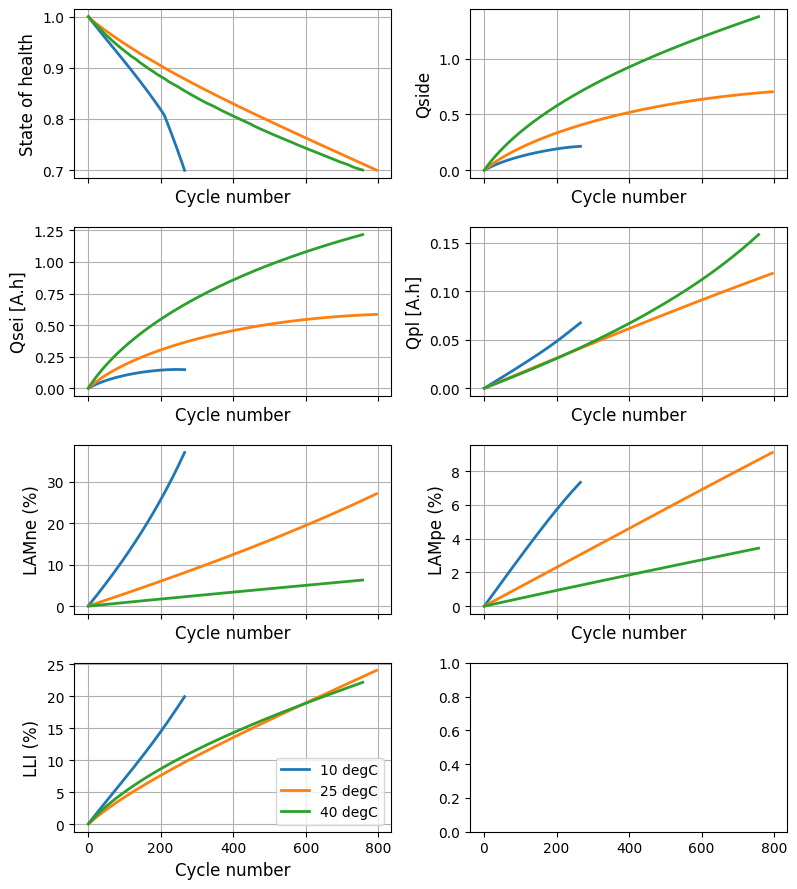

In [ ]:
df3 = pd.read_csv(f"{current_directory}/paperstudies2026/tuning/Cases_tuning_std300.csv")
cycles_per_day =1


fig, axes = plt.subplots(4, 2, figsize=(8,9), sharex=True)
axes = axes.flatten()
for m in range(3):#,29,31,33,35,37,39,43,45,47,49,51,53,59,65,67,69,71,77,81]: #range(27,54):#: #range(5): #
   
    n = m
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    dod_case = df3["DoD"][n]*0.01
    soc_case = df3["SoC"][n]*0.01
    crate = df3["C_rate"][n]
    df4 = pd.read_csv(f"{current_directory}/paperstudies2026/tuning/tune_Case{simcase}_{tempC_case}degC_std300.csv")
    
    xcycle = df4["Cycle number"]
    
    variables = ["Capacity Retention", "Qside", "Qsei", "Qpl", "LAMne_per", "LAMpe_per",  "LLIp", ]
    variables2 = ["State of health", "Qside", "Qsei [A.h]", "Qpl [A.h]", "LAMne (%)", "LAMpe (%)",  "LLI (%)", ]
    
    for i, var in enumerate(variables):

        axes[i].plot(xcycle, df4[var], label = f"{tempC_case} degC", linewidth=2)
        #axes[i].set_title(var)
        
            # X-axis label
        axes[i].set_ylabel(f"{variables2[i]}",fontsize=12)         # Y-axis label
        
        axes[i].set_xlabel("Cycle number", fontsize=12) 
        axes[i].grid(True)
    axes[i].legend()
#plt.xlabel("Cycle number") 

plt.tight_layout()
plt.show()


In [327]:
# plt.rc('font', size=14)          # default text
# plt.rc('axes', titlesize=16)     # title
# plt.rc('axes', labelsize=14)     # axis labels
# plt.rc('xtick', labelsize=12)    # x tick labels
# plt.rc('ytick', labelsize=12)    # y tick labels
# plt.rc('legend', fontsize=12)    # legend
# pybamm.dynamic_plot(
#     sim1,
#     output_variables =[
        
#         "Terminal voltage [V]",
#         "Current [A]",
#         "X-averaged cell temperature [K]",
        
#     ])

In [328]:
# t1 = sim1.solution["Time [h]"].entries
# Vc1 = sim1.solution["Terminal voltage [V]"].entries
# Temp1 = sim1.solution["X-averaged cell temperature [K]"].entries

# plt.plot(t1, Vc1)
# plt.show()
# plt.plot(t1, Temp1)

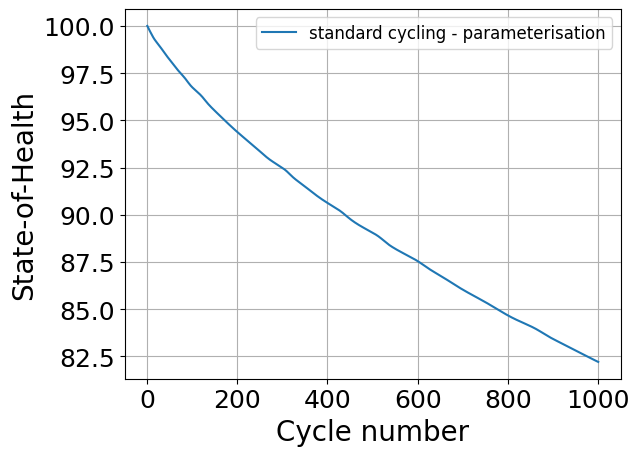

In [34]:
Q1 = sim1.solution.summary_variables["Capacity [A.h]"]
cycle1 = sim1.solution.summary_variables["Cycle number"]
plt.plot(cycle1, 100*(Q1/Q1[0]), label = "standard cycling - parameterisation")
plt.legend(fontsize=12)

plt.xlabel('Cycle number',fontsize=20)
plt.ylabel('State-of-Health',fontsize=20)
# plt.title('SoH of a Lithium-Ion Cell-DFN Model',fontsize=20)
#plt.ylim([75, 101])
# #plt.xlim([-50, 500])
# plt.legend(fontsize=9)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True)
# plt.show()

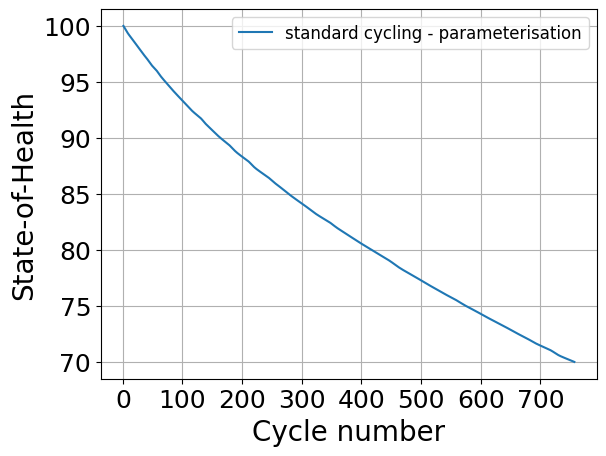

In [191]:
Q1 = sim1.solution.summary_variables["Capacity [A.h]"]
cycle1 = sim1.solution.summary_variables["Cycle number"]
plt.plot(cycle1, 100*(Q1/Q1[0]), label = "standard cycling - parameterisation")
plt.legend(fontsize=12)

plt.xlabel('Cycle number',fontsize=20)
plt.ylabel('State-of-Health',fontsize=20)
# plt.title('SoH of a Lithium-Ion Cell-DFN Model',fontsize=20)
#plt.ylim([75, 101])
# #plt.xlim([-50, 500])
# plt.legend(fontsize=9)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True)
# plt.show()

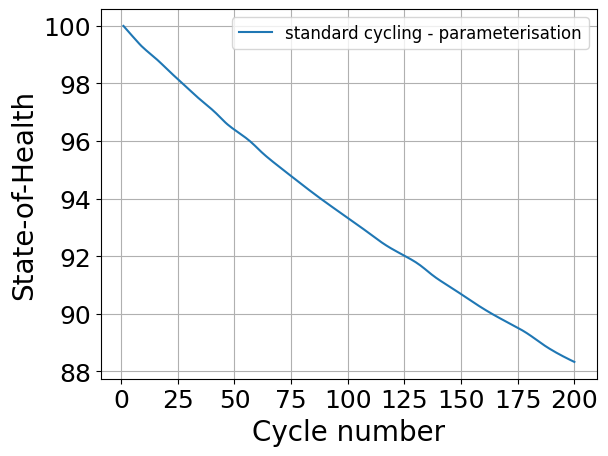

In [180]:
Q1 = sim1.solution.summary_variables["Capacity [A.h]"]
cycle1 = sim1.solution.summary_variables["Cycle number"]
plt.plot(cycle1, 100*(Q1/Q1[0]), label = "standard cycling - parameterisation")
plt.legend(fontsize=12)

plt.xlabel('Cycle number',fontsize=20)
plt.ylabel('State-of-Health',fontsize=20)
# plt.title('SoH of a Lithium-Ion Cell-DFN Model',fontsize=20)
#plt.ylim([75, 101])
# #plt.xlim([-50, 500])
# plt.legend(fontsize=9)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True)
# plt.show()

In [ ]:
#sim1.plot(["Negative electrode porosity", "Positive electrode porosity"])

interactive(children=(FloatSlider(value=0.0, description='t', max=2664.4112927570236, step=26.644112927570237)…

In [181]:
#pybamm.plot_summary_variables(sim1.solution)

In [22]:
sim1.plot()

interactive(children=(FloatSlider(value=0.0, description='t', max=1722.4753794927897, step=17.224753794927896)…

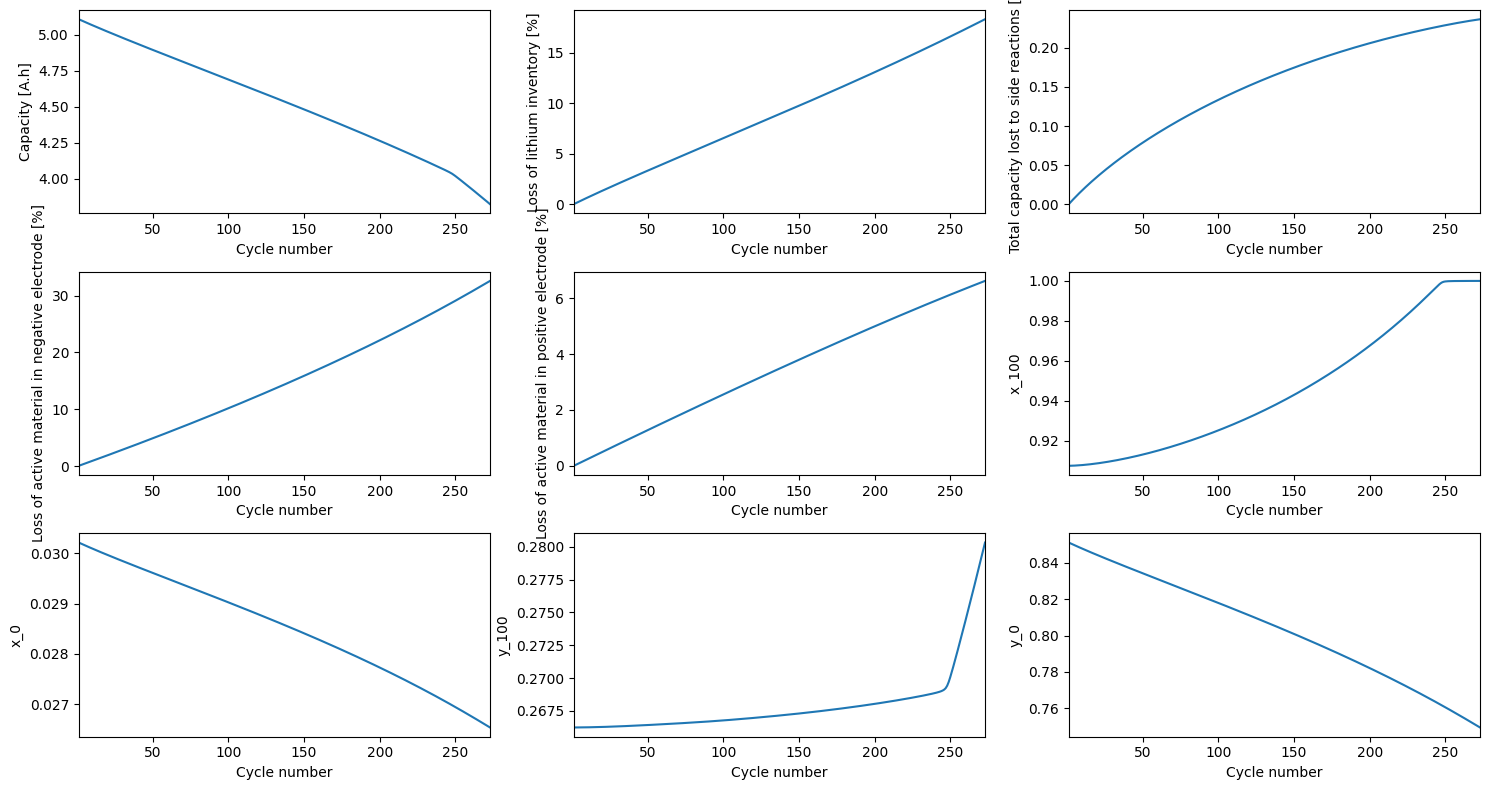

array([[<Axes: xlabel='Cycle number', ylabel='Capacity [A.h]'>,
        <Axes: xlabel='Cycle number', ylabel='Loss of lithium inventory [%]'>,
        <Axes: xlabel='Cycle number', ylabel='Total capacity lost to side reactions [A.h]'>],
       [<Axes: xlabel='Cycle number', ylabel='Loss of active material in negative electrode [%]'>,
        <Axes: xlabel='Cycle number', ylabel='Loss of active material in positive electrode [%]'>,
        <Axes: xlabel='Cycle number', ylabel='x_100'>],
       [<Axes: xlabel='Cycle number', ylabel='x_0'>,
        <Axes: xlabel='Cycle number', ylabel='y_100'>,
        <Axes: xlabel='Cycle number', ylabel='y_0'>]], dtype=object)

In [13]:
pybamm.plot_summary_variables(sim1.solution)

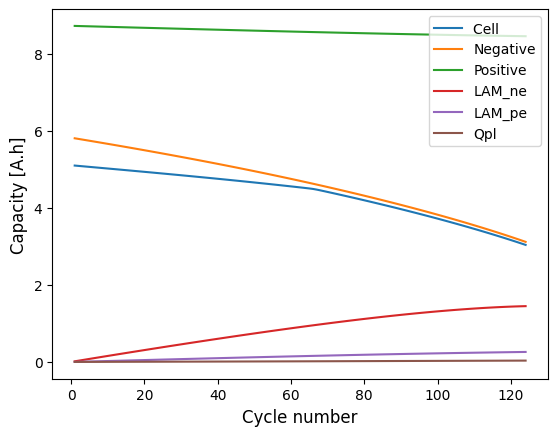

In [68]:
Q1 = sim1.solution.summary_variables["Capacity [A.h]"]
Qnes = sim1.solution.summary_variables["Negative electrode capacity [A.h]"]
Qpes = sim1.solution.summary_variables["Positive electrode capacity [A.h]"]
Qpl=  sim1.solution.summary_variables["Loss of capacity to negative lithium plating [A.h]"]

mlam_n = sim1.solution.summary_variables['Loss of active material in negative electrode [%]']
mlam_p = sim1.solution.summary_variables['Loss of active material in positive electrode [%]']
cycle1s = sim1.solution.summary_variables["Cycle number"]

r1 = [a*b/100 for a, b in zip(mlam_n,Qnes)]
r2 = [a*b/100 for a, b in zip(mlam_p,Qpes)]
plt.plot(cycle1s, Q1, label="Cell ")
plt.plot(cycle1s, Qnes, label="Negative")
plt.plot(cycle1s, Qpes, label="Positive")
plt.plot(cycle1s, r1, label="LAM_ne")
plt.plot(cycle1s, r2, label="LAM_pe")
plt.plot(cycle1s, Qpl, label="Qpl")

plt.xlabel('Cycle number',fontsize=12)
plt.ylabel('Capacity [A.h]',fontsize=12)
plt.legend()


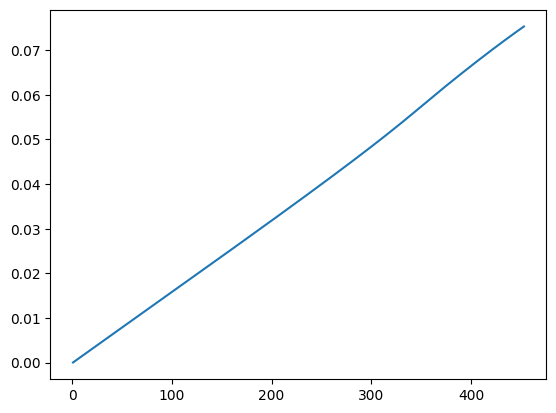

In [59]:
plt.plot(cycle1s, Qpl, label="Qpl")

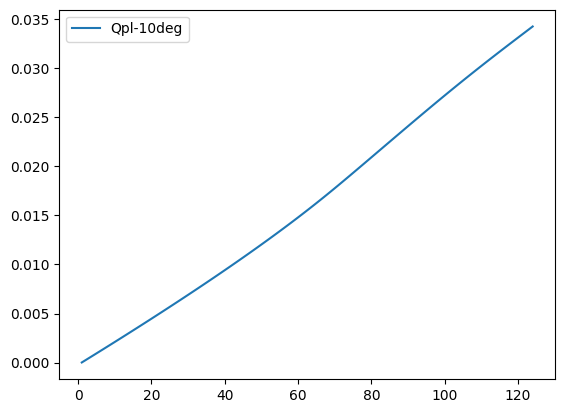

In [69]:
plt.plot(cycle1s, Qpl, label="Qpl-10deg")
plt.legend()

In [ ]:
Q1 = sim1.solution.summary_variables["Capacity [A.h]"]
    cycle1 = sim1.solution.summary_variables["Cycle number"]
    Qpl=  sim1.solution.summary_variables["Loss of capacity to negative lithium plating [A.h]"]

    mlam_n = sim1.solution.summary_variables['Loss of active material in negative electrode [%]']
    mlam_p = sim1.solution.summary_variables['Loss of active material in positive electrode [%]']
    Qlli = sim1.solution.summary_variables['Loss of lithium inventory [%]']
    Qside = sim1.solution.summary_variables["Total capacity lost to side reactions [A.h]"]
    Qsei  = sim1.solution.summary_variables['Loss of capacity to negative SEI [A.h]']
    